# Generating the controlled LISA PSD data set

## Aim

Construct a year-long TDI XYZ archive with separately stored instrumental-noise and Galactic-foreground realizations:

$$S_{\rm total}(t,f)=S_{\rm noise}(t,f)+S_{\rm gal}(t,f).$$

The archive is designed to test local-PSD inference. It contains random time series, deterministic ensemble PSDs for post-fit checks, a fixed Galactic response template, and an analytic OMS/TM reference that may be reduced to weak scalar calibration information.

### Methods synopsis

We add independent instrumental-noise and Galactic-foreground time series channel by channel. The Galactic realization is generated from a prescribed time-dependent PSD using overlapping square-root-filter blocks. The deterministic component surfaces describe ensemble variances; a single realization fluctuates around them.


## 1. Generative model

1. Load the second-generation XYZ instrumental-noise realization and its ESA spacecraft orbits.
2. Evaluate the OMS/TM TDI-noise auto-PSDs on a coarse time--frequency grid.
3. Propagate a fixed Milky-Way sky map through the time-dependent LISA response and apply the adopted Galactic spectrum.
4. Draw a nonstationary Galactic realization using overlapping square-root-filter blocks.
5. Add the independent instrumental and Galactic time series channel by channel.

Multiplication by the squared laser carrier frequency converts fractional-frequency response PSDs to the archived one-sided TDI PSD convention.

## 2. Archive contract and assumptions

- `tdi/noise`, `tdi/galactic`, `tdi/total`: random time-domain realizations.
- `truth/*_psd`: deterministic injection expectations used for post-fit recovery checks.
- `model/galactic_template_psd`: fixed orbit-and-sky response at unit Galactic amplitude.
- `model/noise_baseline_psd`: analytic OMS/TM reference stored for diagnostics and optional weak calibration.

The M1 analyses in the fitting notebooks do **not** pass `model/noise_baseline_psd(t,f)` to the likelihood. They collapse it to one geometric-mean PSD level per fitted channel and let a free P-spline learn the complete noise shape. Thus the likelihood is not given the simulated OMS/TM time-frequency surface. The full reference remains useful for identifying genuine transfer minima in simulation-only diagnostic plots.

The Galactic response and sky map are assumed known. This is a scientific modelling assumption, not knowledge of the random Galactic realization. Response/sky mismatch, OMS/TM level mismatch, and repeated random seeds are separate robustness studies.


In [1]:
# JAX must be configured before importing backgrounds: float32 underflows physical PSDs (~1e-40).
import os
os.environ.setdefault("JAX_ENABLE_X64", "true")

from pathlib import Path
import json
import warnings

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.signal import resample_poly, welch

import jax
jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=UserWarning, module="lisaconstants")

from backgrounds import StochasticBackgroundResponse, noise as background_noise, signal, tdi
from lisaorbits import InterpolatedOrbits
from wdm_transform import TimeSeries


## 3. Numerical configuration

The parameter cell records cadence, frequency range, sky-map resolution, Galactic amplitude, synthesis overlap, random seed, and archive path. Set `RUN_FULL_GENERATION=True` only when rebuilding the archive; the default path diagnoses the existing realization.

In [2]:
WORKDIR = Path.cwd().resolve()
ROOT = WORKDIR if (WORKDIR / "noise2a").exists() else WORKDIR / "lisa_data_generation"
NOISE_TDI_PATH = ROOT / "noise2a" / "tdi.h5"
ESA_ORBITS_PATH = ROOT / "noise2a" / "orbits.h5"
OUTPUT_PATH = ROOT / "combined_esa_xyz.h5"

CHANNELS = ("X2", "Y2", "Z2")
SECONDS_PER_YEAR = 365.25 * 24 * 3600
CARRIER_FREQUENCY_HZ = 281_600_000_000_000.0
TARGET_DT = 2.0
FREQ_MIN_HZ = 1.0e-4
FREQ_MAX_HZ = 1.0e-1
N_TRUTH_FREQUENCIES = 256
GALACTIC_MAP_NSIDE = 8
GALACTIC_MAP_RADIAL_POINTS = 400
GALACTIC_AMPLITUDE_SCALE = 0.8432771370761396
SYNTHESIS_LENGTH = 2**19       # 12.1 d at 2 s
SYNTHESIS_HOP = SYNTHESIS_LENGTH // 2
SEED = 20260805
RUN_FULL_GENERATION = False

for path in (NOISE_TDI_PATH, ESA_ORBITS_PATH):
    if not path.exists():
        raise FileNotFoundError(path)
if TARGET_DT / 2.0 != round(TARGET_DT / 2.0):
    raise ValueError("TARGET_DT must be an integer multiple of the noise2a cadence.")
if FREQ_MAX_HZ >= 0.5 / TARGET_DT:
    raise ValueError("FREQ_MAX_HZ must be below the output Nyquist frequency.")

## 4. Construction

### 4.1 Deterministic component surfaces

The ESA orbit interpolation is reused by both the analytic OMS/TM model and the Galactic response. Both components are evaluated on the same coarse time--frequency grid before any random foreground samples are drawn.

In [3]:
def load_esa_orbits(path: Path) -> tuple[InterpolatedOrbits, float, float]:
    """Return an orbit interpolator built from the archived ESA OEM positions."""
    with h5py.File(path, "r") as hdf:
        t0 = float(hdf.attrs["t0"])
        dt = float(hdf.attrs["dt"])
        size = int(hdf.attrs["size"])
        time_tcb = t0 + dt * np.arange(size)
        positions = hdf["tcb/x"][:]
    return (
        InterpolatedOrbits(time_tcb, positions, t_init=t0, interp_order=5, extrapolate=False),
        t0,
        dt,
    )


def galactic_sky_map(nside: int, radial_points: int) -> tuple[np.ndarray, signal.Galaxy]:
    """An anisotropic Milky-Way amplitude map and its one-year strain PSD."""
    galaxy = signal.Galaxy(nside=nside, tobs_yrs=1.0)
    power = galaxy.compute_map(
        n_points=radial_points, lmin=1.0e-3, lmax=20.0, xsun=-8.1, coord="C"
    )
    if not np.all(np.isfinite(power)) or np.any(power < 0):
        raise RuntimeError("Galactic sky map is not a finite non-negative power map.")
    return np.sqrt(power / power.sum()), galaxy


def diagonal_psd(covariance: np.ndarray) -> np.ndarray:
    """Convert (frequency, time, channel, channel) covariance to (channel, time, frequency)."""
    diagonal = np.real(np.diagonal(covariance, axis1=-2, axis2=-1))
    return np.moveaxis(diagonal, (0, 1, 2), (2, 1, 0))


def component_truth(orbits: InterpolatedOrbits, time_tcb: np.ndarray, frequency_hz: np.ndarray):
    """Compute ESA-orbit XYZ noise and Galactic auto-PSD surfaces in physical Hz^-1."""
    sky_map, galaxy = galactic_sky_map(GALACTIC_MAP_NSIDE, GALACTIC_MAP_RADIAL_POINTS)

    # These are the values used in noise2a/noise-2.ipynb.  fs and duration retain
    # its sampled-noise convention rather than substituting a generic SciRD curve.
    oms = background_noise.AnalyticOMSNoiseModel(
        frequency_hz, time_tcb, orbits, tdi_tf_func=tdi.compute_tdi_tf, gen="2.0",
        oms_isi_carrier_asds=7.9e-12, fs=0.5, duration=SECONDS_PER_YEAR,
    )
    test_mass = background_noise.AnalyticTMNoiseModel(
        frequency_hz, time_tcb, orbits, tdi_tf_func=tdi.compute_tdi_tf_tm, gen="2.0",
        tm_isi_carrier_asds=2.4e-15, fs=0.5, duration=SECONDS_PER_YEAR,
    )
    # backgrounds returns fractional-frequency PSDs. noise2a TDI samples are in Hz,
    # so convert *both* components to Hz^2 / Hz before combining or synthesizing.
    s_noise = diagonal_psd(oms.compute_covariances(0.0) + test_mass.compute_covariances(0.0)) * CARRIER_FREQUENCY_HZ**2

    response = StochasticBackgroundResponse(sky_map, orbits=orbits)
    galactic_kernel = response.compute_tdi_kernel(frequency_hz, time_tcb, tdi_var="xyz", gen="2.0")
    response_diagonal = diagonal_psd(galactic_kernel)
    s_galactic = response_diagonal * galaxy.psd(frequency_hz)[None, None, :] * CARRIER_FREQUENCY_HZ**2

    if not (np.all(np.isfinite(s_noise)) and np.all(np.isfinite(s_galactic))):
        raise RuntimeError("Non-finite component truth PSD. Confirm JAX float64 is enabled.")
    return s_noise, s_galactic


### 4.2 Draw the Galactic realization and add the components

For each overlapping block, the response surface supplies a local target PSD. Independent Gaussian frequency coefficients are scaled by that PSD, transformed to the time domain, and combined with a square-root-Hann window. At 50% overlap the squared windows sum to a constant, preserving power through overlap-add. The Galactic samples are then added directly to the existing instrumental-noise samples.

In [4]:
def surface_interpolators(time_tcb: np.ndarray, frequency_hz: np.ndarray, surface: np.ndarray):
    """Log-PSD interpolators, one for each XYZ channel."""
    return [
        RegularGridInterpolator(
            (time_tcb, np.log(frequency_hz)),
            np.log(np.maximum(surface[channel], 1.0e-300)),
            bounds_error=False, fill_value=np.nan,
        )
        for channel in range(len(CHANNELS))
    ]


def evaluate_surface(interpolators, time_tcb: float, fft_frequency_hz: np.ndarray) -> np.ndarray:
    """Evaluate a truth surface at one segment centre."""
    result = np.zeros((len(CHANNELS), fft_frequency_hz.size))
    valid = (fft_frequency_hz >= FREQ_MIN_HZ) & (fft_frequency_hz <= FREQ_MAX_HZ)
    points = np.column_stack((np.full(valid.sum(), time_tcb), np.log(fft_frequency_hz[valid])))
    for channel, interpolator in enumerate(interpolators):
        values = interpolator(points)
        if not np.all(np.isfinite(values)):
            raise RuntimeError("Synthesis asked for a point outside the truth grid.")
        result[channel, valid] = np.exp(values)
    return result


def draw_colored_series(psd: np.ndarray, dt_seconds: float, rng: np.random.Generator) -> np.ndarray:
    """Draw one real series under S(f_k)=2 dt |rfft(x)_k|^2 / n."""
    n = 2 * (psd.size - 1)
    spectrum = np.zeros(psd.size, dtype=complex)
    spectrum[1:-1] = np.sqrt(psd[1:-1] * n / (4.0 * dt_seconds)) * (
        rng.standard_normal(psd.size - 2) + 1j * rng.standard_normal(psd.size - 2)
    )
    spectrum[0] = np.sqrt(psd[0] * n / (2.0 * dt_seconds)) * rng.standard_normal()
    spectrum[-1] = np.sqrt(psd[-1] * n / (2.0 * dt_seconds)) * rng.standard_normal()
    return np.fft.irfft(spectrum, n=n)


def synthesize_galactic_component(interpolators, start_tcb: float, n_samples: int, dt_seconds: float, rng):
    """Segment-by-segment ESA Galactic realization with overlap-add."""
    if n_samples % SYNTHESIS_HOP:
        raise ValueError("n_samples must be a multiple of SYNTHESIS_HOP.")
    frequency = np.fft.rfftfreq(SYNTHESIS_LENGTH, dt_seconds)
    window = np.sin(np.pi * (np.arange(SYNTHESIS_LENGTH) + 0.5) / SYNTHESIS_LENGTH)
    padded = np.zeros((len(CHANNELS), n_samples + 2 * SYNTHESIS_HOP))
    n_segments = n_samples // SYNTHESIS_HOP + 1
    for index in range(n_segments):
        psd = evaluate_surface(interpolators, start_tcb + index * SYNTHESIS_HOP * dt_seconds, frequency)
        for channel in range(len(CHANNELS)):
            padded[channel, index * SYNTHESIS_HOP:index * SYNTHESIS_HOP + SYNTHESIS_LENGTH] += (
                window * draw_colored_series(psd[channel], dt_seconds, rng)
            )
    return padded[:, SYNTHESIS_HOP:SYNTHESIS_HOP + n_samples]


def load_noise2a(path: Path) -> tuple[np.ndarray, float, float]:
    """Read noise2a, decimating only when TARGET_DT exceeds its 2 s cadence."""
    with h5py.File(path, "r") as hdf:
        native_dt = float(hdf.attrs["dt"])
        t0 = float(hdf.attrs["t0"])
        factor = int(round(TARGET_DT / native_dt))
        if not np.isclose(native_dt * factor, TARGET_DT):
            raise ValueError(f"Cannot map native dt={native_dt} to TARGET_DT={TARGET_DT}.")
        data = np.stack([
            hdf[channel][:] if factor == 1 else resample_poly(hdf[channel][:], up=1, down=factor)
            for channel in CHANNELS
        ])
    return data, t0, native_dt

### 4.3 Galactic realization

For each overlapping block, the local PSD is square-root filtered in frequency space. Independent Gaussian coefficients generate one realization whose ensemble variance follows the interpolated Galactic surface. Overlap-add windows suppress block boundaries.

In [5]:
def build_dataset(output_path: Path) -> dict:
    orbits, orbit_t0, _ = load_esa_orbits(ESA_ORBITS_PATH)
    noise_series, data_t0, native_dt = load_noise2a(NOISE_TDI_PATH)
    n_samples = (noise_series.shape[1] // SYNTHESIS_HOP) * SYNTHESIS_HOP
    noise_series = noise_series[:, :n_samples]

    truth_time_tcb = data_t0 + np.arange(n_samples // SYNTHESIS_HOP + 1) * SYNTHESIS_HOP * TARGET_DT
    if truth_time_tcb[0] < orbit_t0 or truth_time_tcb[-1] > orbit_t0 + 632 * 100000.0:
        raise RuntimeError("Requested data span is outside the ESA orbit coverage.")
    truth_frequency_hz = np.geomspace(FREQ_MIN_HZ, FREQ_MAX_HZ, N_TRUTH_FREQUENCIES)

    noise_psd, galactic_template_psd = component_truth(orbits, truth_time_tcb, truth_frequency_hz)
    # These are external model inputs for component inference, not fitted
    # realization truth: analytic TDI noise and an orbit/sky-response
    # Galactic template at unit amplitude.  The inference fits its amplitude.
    galactic_psd = GALACTIC_AMPLITUDE_SCALE * galactic_template_psd
    total_psd = noise_psd + galactic_psd

    rng = np.random.default_rng(SEED)
    galactic_series = synthesize_galactic_component(
        surface_interpolators(truth_time_tcb, truth_frequency_hz, galactic_psd),
        data_t0, n_samples, TARGET_DT, rng,
    )
    total_series = noise_series + galactic_series

    if output_path.exists():
        output_path.unlink()
    with h5py.File(output_path, "w") as hdf:
        hdf.attrs.update({
            "t0_tcb": data_t0, "dt_seconds": TARGET_DT, "native_noise_dt_seconds": native_dt,
            "n_samples": n_samples, "channels": ",".join(CHANNELS),
            "psd_convention": "one-sided TDI PSD, Hz^2/Hz",
            "galactic_amplitude_scale": GALACTIC_AMPLITUDE_SCALE,
            "noise_source": str(NOISE_TDI_PATH), "orbit_source": str(ESA_ORBITS_PATH),
        })
        hdf.create_dataset("time_seconds", data=np.arange(n_samples) * TARGET_DT, compression="lzf")
        tdi_group = hdf.create_group("tdi")
        for name, values in {"noise": noise_series, "galactic": galactic_series, "total": total_series}.items():
            tdi_group.create_dataset(name, data=values, compression="lzf", shuffle=True)
        model = hdf.create_group("model")
        model.attrs.update({
            "description": "External response-informed component-model inputs",
            "galactic_template_reference_f_knee_hz": 2.15e-3,
            "galactic_template_amplitude": 1.0,
        })
        model.create_dataset("time_tcb", data=truth_time_tcb)
        model.create_dataset("frequency_hz", data=truth_frequency_hz)
        model.create_dataset("noise_baseline_psd", data=noise_psd, compression="lzf", shuffle=True)
        model.create_dataset("galactic_template_psd", data=galactic_template_psd, compression="lzf", shuffle=True)
        truth = hdf.create_group("truth")
        truth.create_dataset("time_tcb", data=truth_time_tcb)
        truth.create_dataset("frequency_hz", data=truth_frequency_hz)
        for name, values in {"noise_psd": noise_psd, "galactic_psd": galactic_psd, "total_psd": total_psd}.items():
            truth.create_dataset(name, data=values, compression="lzf", shuffle=True)

    return {"output": str(output_path), "shape": tuple(total_series.shape),
            "duration_days": n_samples * TARGET_DT / 86400.0,
            "truth_shape": tuple(total_psd.shape)}


if RUN_FULL_GENERATION:
    print(json.dumps(build_dataset(OUTPUT_PATH), indent=2))
else:
    print("Set RUN_FULL_GENERATION = True to create:", OUTPUT_PATH)

Set RUN_FULL_GENERATION = True to create: /Users/avi/Documents/projects/wdm_psd/lisa_data_generation/combined_esa_xyz.h5


### 4.4 Archive identity

The stored total is checked sample by sample:

$$d_{\rm total}=d_{\rm noise}+d_{\rm gal}.$$

The deterministic truth obeys the analogous PSD sum because the component realizations are independent. Random seeds, source paths, conventions, and synthesis parameters are stored as provenance.

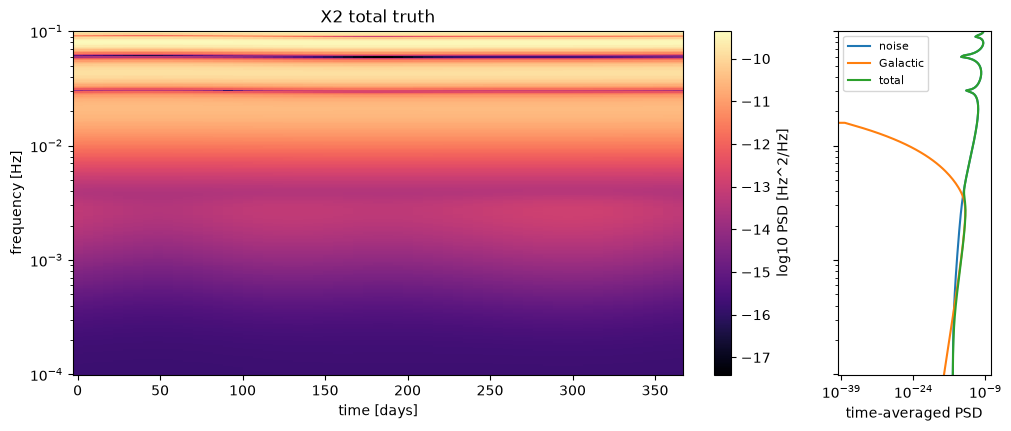

{'galactic_modulation_range': 4.022174501136531}


In [6]:
def inspect_dataset(path: Path):
    with h5py.File(path, "r") as hdf:
        frequency = hdf["truth/frequency_hz"][:]
        time_days = (hdf["truth/time_tcb"][:] - hdf.attrs["t0_tcb"]) / 86400.0
        noise_psd = hdf["truth/noise_psd"][:]
        galactic_psd = hdf["truth/galactic_psd"][:]
        total_psd = hdf["truth/total_psd"][:]

    assert np.array_equal(total_psd, noise_psd + galactic_psd)
    fig = plt.figure(figsize=(10, 4.2), constrained_layout=True)
    grid = fig.add_gridspec(1, 2, width_ratios=(4, 1), wspace=0.06)
    surface_axis = fig.add_subplot(grid[0])
    average_axis = fig.add_subplot(grid[1], sharey=surface_axis)

    image = surface_axis.pcolormesh(time_days, frequency, np.log10(total_psd[0]).T, shading="auto", cmap="magma")
    surface_axis.set(xlabel="time [days]", ylabel="frequency [Hz]", yscale="log", title="X2 total truth")
    fig.colorbar(image, ax=surface_axis, label="log10 PSD [Hz^2/Hz]")
    for surface, label in ((noise_psd, "noise"), (galactic_psd, "Galactic"), (total_psd, "total")):
        average_axis.loglog(surface[0].mean(axis=0), frequency, label=label)
    average_axis.set(xlabel="time-averaged PSD", yscale="log")
    average_axis.tick_params(labelleft=False)
    average_axis.legend(fontsize=8)
    plt.show()
    return {"galactic_modulation_range": float(galactic_psd[0].mean(axis=1).max() / galactic_psd[0].mean(axis=1).min())}


if OUTPUT_PATH.exists():
    print(inspect_dataset(OUTPUT_PATH))
else:
    print("No output archive yet.")

### 5.2 WDM realization check

The calibrated WDM power from one X2 realization is compared with the deterministic total surface. Agreement is expected only after averaging: the truth is an ensemble variance, whereas each WDM pixel is one noisy power draw.

{
  "figure": "/Users/avi/Documents/projects/wdm_psd/lisa_data_generation/wdm_x2_truth_and_realization.png",
  "wdm_shape": [
    1,
    64,
    245761
  ],
  "time_pixel_days": 5.688888888888889,
  "mean_observed_over_model": 1.088085033205614,
  "median_observed_over_model": 0.45921409719945966
}


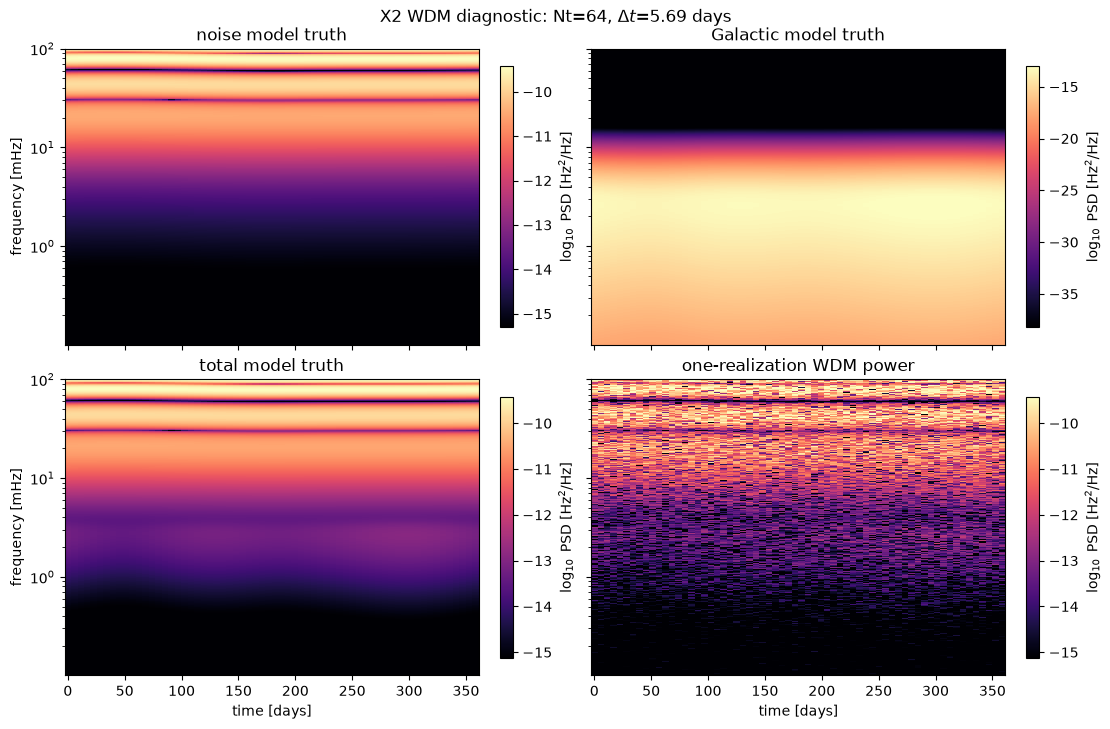

In [7]:
WDM_NT = 64  # 5.69-day WDM time pixels for the generated 364-day archive.
WDM_FIGURE_PATH = ROOT / "wdm_x2_truth_and_realization.png"


def local_psd_on_wdm_grid(truth_time_tcb, truth_frequency_hz, surface, data_t0, wdm):
    """Interpolate one local-PSD model from the synthesis grid to WDM pixel centres."""
    wdm_time_tcb = data_t0 + np.asarray(wdm.time_grid)
    wdm_frequency_hz = np.asarray(wdm.freq_grid)
    valid = (wdm_frequency_hz >= truth_frequency_hz[0]) & (wdm_frequency_hz <= truth_frequency_hz[-1])
    interpolator = RegularGridInterpolator(
        (truth_time_tcb, np.log(truth_frequency_hz)),
        np.log(np.maximum(surface, 1.0e-300)),
        bounds_error=True,
    )
    output = np.full((wdm.nt, wdm_frequency_hz.size), np.nan)
    time_mesh, frequency_mesh = np.meshgrid(wdm_time_tcb, np.log(wdm_frequency_hz[valid]), indexing="ij")
    output[:, valid] = np.exp(interpolator(np.column_stack((time_mesh.ravel(), frequency_mesh.ravel())))).reshape(time_mesh.shape)
    return output, valid


def wdm_white_calibration(n_samples: int, dt_seconds: float, nt: int, seed: int = 20260806):
    """Mean WDM coefficient variance for a unit-variance white series on this exact grid."""
    rng = np.random.default_rng(seed)
    estimates = []
    for _ in range(8):
        white_wdm = TimeSeries(rng.standard_normal(n_samples), dt_seconds).to_wdm(nt=nt)
        estimates.append(np.mean(np.asarray(white_wdm.coeffs)[0] ** 2, axis=0))
    return np.mean(estimates, axis=0)


def plot_wdm_x2(path: Path, figure_path: Path, nt: int = WDM_NT):
    """Save model components, total model, and one-realization WDM power for X2."""
    with h5py.File(path, "r") as hdf:
        total = hdf["tdi/total"][0]
        data_t0 = float(hdf.attrs["t0_tcb"])
        dt_seconds = float(hdf.attrs["dt_seconds"])
        truth_time_tcb = hdf["truth/time_tcb"][:]
        truth_frequency_hz = hdf["truth/frequency_hz"][:]
        noise_truth = hdf["truth/noise_psd"][0]
        galactic_truth = hdf["truth/galactic_psd"][0]
        total_truth = hdf["truth/total_psd"][0]

    wdm = TimeSeries(total, dt_seconds).to_wdm(nt=nt)
    calibration = wdm_white_calibration(total.size, dt_seconds, nt)
    # White noise with variance one has one-sided PSD 2 dt; this converts WDM power to Hz^-1.
    observed_psd = 2.0 * dt_seconds * np.asarray(wdm.coeffs)[0] ** 2 / calibration[None, :]
    noise_wdm, valid = local_psd_on_wdm_grid(truth_time_tcb, truth_frequency_hz, noise_truth, data_t0, wdm)
    galactic_wdm, _ = local_psd_on_wdm_grid(truth_time_tcb, truth_frequency_hz, galactic_truth, data_t0, wdm)
    total_wdm, _ = local_psd_on_wdm_grid(truth_time_tcb, truth_frequency_hz, total_truth, data_t0, wdm)

    time_days = np.asarray(wdm.time_grid) / 86400.0
    frequency_mhz = np.asarray(wdm.freq_grid)[valid] * 1.0e3
    component_fields = (noise_wdm[:, valid], galactic_wdm[:, valid])
    total_fields = (total_wdm[:, valid], observed_psd[:, valid])

    def robust_limits(field):
        values = np.log10(field[np.isfinite(field) & (field > 1.0e-100)])
        return np.quantile(values, (0.01, 0.99))

    total_limits = robust_limits(total_fields[0])
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True, constrained_layout=True)
    panels = (
        (axes[0, 0], component_fields[0], "noise model truth", robust_limits(component_fields[0])),
        (axes[0, 1], component_fields[1], "Galactic model truth", robust_limits(component_fields[1])),
        (axes[1, 0], total_fields[0], "total model truth", total_limits),
        (axes[1, 1], total_fields[1], "one-realization WDM power", total_limits),
    )
    for axis, field, title, (vmin, vmax) in panels:
        image = axis.pcolormesh(time_days, frequency_mhz, np.log10(np.maximum(field, 1.0e-100)).T, shading="nearest", cmap="magma", vmin=vmin, vmax=vmax)
        colorbar = fig.colorbar(image, ax=axis, shrink=0.88)
        colorbar.set_label(r"$\log_{10}$ PSD [Hz$^2$/Hz]")
        axis.set(title=title, yscale="log")
    axes[0, 0].set_ylabel("frequency [mHz]")
    axes[1, 0].set_ylabel("frequency [mHz]")
    axes[1, 0].set_xlabel("time [days]")
    axes[1, 1].set_xlabel("time [days]")
    fig.suptitle(rf"X2 WDM diagnostic: Nt={wdm.nt}, $\Delta t$={wdm.delta_t / 86400:.2f} days", y=1.02)
    fig.savefig(figure_path, dpi=180, bbox_inches="tight")

    ratio = observed_psd[:, valid] / total_wdm[:, valid]
    return {
        "figure": str(figure_path), "wdm_shape": tuple(np.asarray(wdm.coeffs).shape),
        "time_pixel_days": float(wdm.delta_t / 86400.0),
        "mean_observed_over_model": float(np.nanmean(ratio)),
        "median_observed_over_model": float(np.nanmedian(ratio)),
    }


if OUTPUT_PATH.exists():
    print(json.dumps(plot_wdm_x2(OUTPUT_PATH, WDM_FIGURE_PATH), indent=2))
else:
    print("No output archive yet; generate it before running the WDM diagnostic.")

### 5.3 Independent SEGWO check

SEGWO provides a second local covariance estimate. It checks the generated scale and annual modulation independently of the WDM representation used for inference.

#### Local auto-PSD estimates

The time--frequency panels show the realization-level estimates; the side panels show time averages. Broad agreement with the deterministic components is the relevant check, not pixelwise equality.

In [8]:
from scipy.ndimage import uniform_filter, uniform_filter1d
from segwo_time_frequency import add_independent_covariances, estimate_hdf5_tdi_component

ARCHIVE_PATH = OUTPUT_PATH
SEGWO_SEGMENT_SAMPLES = 2**19
SEGWO_HOP_SAMPLES = SEGWO_SEGMENT_SAMPLES // 2
SEGWO_FREQUENCY_BIN = 8
SEGWO_CHANNEL_INDEX, SEGWO_CHANNEL_NAME = 0, "X2"

In [9]:
segwo_options = dict(
    segment_samples=SEGWO_SEGMENT_SAMPLES,
    hop_samples=SEGWO_HOP_SAMPLES,
    frequency_range_hz=(FREQ_MIN_HZ, FREQ_MAX_HZ),
    frequency_bin=SEGWO_FREQUENCY_BIN,
)
noise_estimate = estimate_hdf5_tdi_component(ARCHIVE_PATH, "noise", **segwo_options)
galactic_estimate = estimate_hdf5_tdi_component(ARCHIVE_PATH, "galactic", **segwo_options)
total_from_components = add_independent_covariances(noise_estimate, galactic_estimate)
total_direct_estimate = estimate_hdf5_tdi_component(ARCHIVE_PATH, "total", **segwo_options)

residual = np.max(np.abs(
    total_from_components.covariance_hz2_per_hz
    - total_from_components.covariance_hz2_per_hz.conj().swapaxes(-1, -2)
))
print(f"{len(noise_estimate.time_tcb)} time windows x {len(noise_estimate.frequency_hz)} frequencies; Hermitian residual {residual:.2e}")

59 time windows x 13094 frequencies; Hermitian residual 1.55e-25


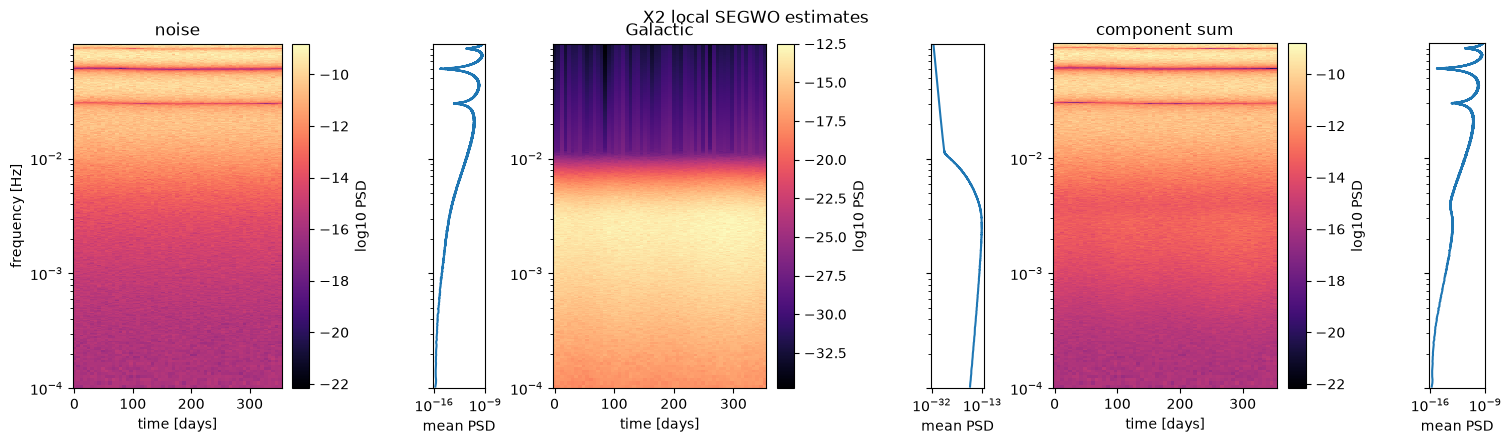

In [10]:
frequency_mask = (noise_estimate.frequency_hz >= FREQ_MIN_HZ) & (noise_estimate.frequency_hz <= FREQ_MAX_HZ)
frequency = noise_estimate.frequency_hz[frequency_mask]
time_days = (noise_estimate.time_tcb - noise_estimate.time_tcb[0]) / 86_400.0

fig = plt.figure(figsize=(15, 4.2), constrained_layout=True)
outer = fig.add_gridspec(1, 3, wspace=0.32)
for index, (estimate, title) in enumerate(zip(
    (noise_estimate, galactic_estimate, total_from_components),
    ("noise", "Galactic", "component sum"),
)):
    grid = outer[index].subgridspec(1, 2, width_ratios=(4, 1), wspace=0.06)
    surface_axis = fig.add_subplot(grid[0])
    average_axis = fig.add_subplot(grid[1], sharey=surface_axis)
    psd = estimate.psd_hz2_per_hz[:, frequency_mask, SEGWO_CHANNEL_INDEX]
    image = surface_axis.pcolormesh(time_days, frequency, np.log10(psd).T, shading="auto", cmap="magma")
    surface_axis.set(title=title, xlabel="time [days]", yscale="log")
    if index == 0:
        surface_axis.set_ylabel("frequency [Hz]")
    fig.colorbar(image, ax=surface_axis, label="log10 PSD")
    average_axis.loglog(np.mean(psd, axis=0), frequency, color="C0")
    average_axis.set(xlabel="mean PSD", yscale="log")
    average_axis.tick_params(labelleft=False)
fig.suptitle(f"{SEGWO_CHANNEL_NAME} local SEGWO estimates", y=1.02)
plt.show()

#### Time-median estimate versus injection

The compact spectra compare SEGWO medians with the injected component surfaces. Their offsets are realization-level diagnostics, not fitted parameters.

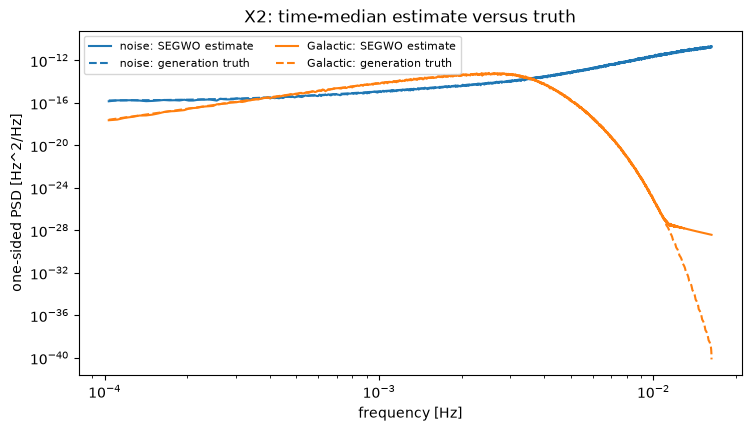

noise median estimate/truth ratio: 0.917
Galactic median estimate/truth ratio: 1.182


In [11]:
def truth_on_estimate_grid(component: str, estimate):
    with h5py.File(ARCHIVE_PATH, "r") as hdf:
        truth_time = hdf["truth/time_tcb"][:]
        truth_frequency = hdf["truth/frequency_hz"][:]
        truth_surface = hdf[f"truth/{component}_psd"][SEGWO_CHANNEL_INDEX]
    interpolate = RegularGridInterpolator(
        (truth_time, truth_frequency), truth_surface, bounds_error=False, fill_value=np.nan
    )
    time_grid, frequency_grid = np.meshgrid(estimate.time_tcb, estimate.frequency_hz, indexing="ij")
    return interpolate(np.column_stack((time_grid.ravel(), frequency_grid.ravel()))).reshape(time_grid.shape)


noise_truth = truth_on_estimate_grid("noise", noise_estimate)
galactic_truth = truth_on_estimate_grid("galactic", galactic_estimate)
comparison_mask = (
    frequency_mask
    & np.isfinite(noise_truth).all(axis=0)
    & np.isfinite(galactic_truth).all(axis=0)
    & (noise_truth > 0.0).all(axis=0)
    & (galactic_truth > 0.0).all(axis=0)
)

fig, axis = plt.subplots(figsize=(7.4, 4.2), constrained_layout=True)
for estimate, truth, colour, label in (
    (noise_estimate, noise_truth, "C0", "noise"),
    (galactic_estimate, galactic_truth, "C1", "Galactic"),
):
    estimate_median = np.nanmedian(estimate.psd_hz2_per_hz[:, comparison_mask, SEGWO_CHANNEL_INDEX], axis=0)
    truth_median = np.nanmedian(truth[:, comparison_mask], axis=0)
    axis.loglog(estimate.frequency_hz[comparison_mask], estimate_median, color=colour, label=f"{label}: SEGWO estimate")
    axis.loglog(estimate.frequency_hz[comparison_mask], truth_median, "--", color=colour, label=f"{label}: generation truth")
axis.set(xlabel="frequency [Hz]", ylabel="one-sided PSD [Hz^2/Hz]", title="X2: time-median estimate versus truth")
axis.legend(ncol=2, fontsize=8)
plt.show()

for name, estimate, truth in (("noise", noise_estimate, noise_truth), ("Galactic", galactic_estimate, galactic_truth)):
    ratio = estimate.psd_hz2_per_hz[:, comparison_mask, SEGWO_CHANNEL_INDEX] / truth[:, comparison_mask]
    print(f"{name} median estimate/truth ratio: {np.nanmedian(ratio):.3f}")

### 5.4 Moving transfer-function minimum

The first X2 minimum is tracked on a linear frequency scale to verify the annual response geometry. This check establishes that the moving dip is present in the simulation; it does not require a generic smooth spline to reproduce its narrow core.

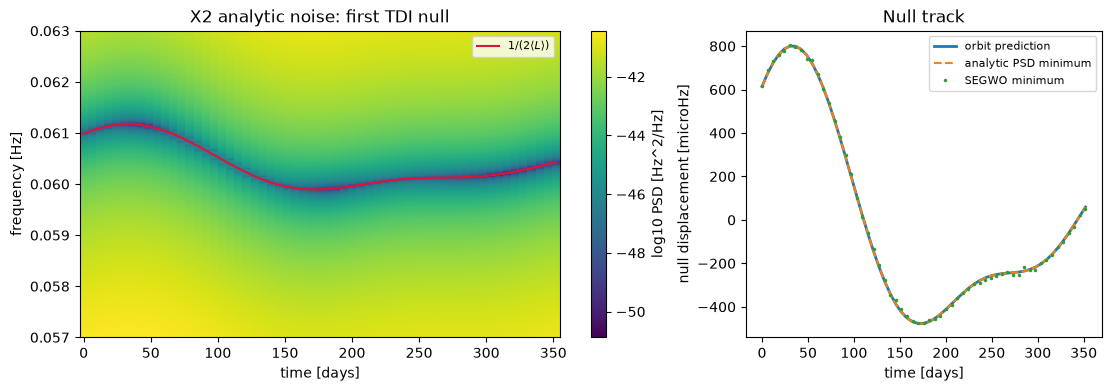

{'orbit_drift_mHz': 1.276945764983592, 'analytic_rms_error_microHz': 0.5821841905665268, 'segwo_rms_error_microHz': 8.63898955955163, 'segwo_correlation': 0.9997963922230069}


In [12]:
def track_minimum(frequency_hz, log_psd, centre_hz, half_width_hz=1.5e-3):
    tracked = []
    for row, centre in zip(log_psd, centre_hz):
        band = np.abs(frequency_hz - centre) < half_width_hz
        local_frequency, local_power = frequency_hz[band], row[band]
        index = np.argmin(local_power)
        if 0 < index < len(local_frequency) - 1:
            quadratic = np.polyfit(
                local_frequency[index - 1:index + 2] - local_frequency[index],
                local_power[index - 1:index + 2], 2,
            )
            tracked.append(local_frequency[index] - quadratic[1] / (2.0 * quadratic[0]))
        else:
            tracked.append(local_frequency[index])
    return np.asarray(tracked)


orbits, _, _ = load_esa_orbits(ESA_ORBITS_PATH)
null_time = noise_estimate.time_tcb
null_frequency = np.linspace(0.057, 0.063, 1201)
oms = background_noise.AnalyticOMSNoiseModel(
    null_frequency, null_time, orbits, tdi_tf_func=tdi.compute_tdi_tf, gen="2.0",
    oms_isi_carrier_asds=7.9e-12, fs=0.5, duration=SECONDS_PER_YEAR,
)
test_mass = background_noise.AnalyticTMNoiseModel(
    null_frequency, null_time, orbits, tdi_tf_func=tdi.compute_tdi_tf_tm, gen="2.0",
    tm_isi_carrier_asds=2.4e-15, fs=0.5, duration=SECONDS_PER_YEAR,
)
analytic_noise = diagonal_psd(oms.compute_covariances(0.0) + test_mass.compute_covariances(0.0))[0]

# X2 uses the four local arms at spacecraft 1; link order is [12, 23, 31, 13, 32, 21].
predicted_null = 1.0 / (2.0 * np.mean(orbits.compute_ltt(null_time, np.array([12, 21, 13, 31])), axis=1))
analytic_null = track_minimum(null_frequency, np.log(analytic_noise), predicted_null)
segwo_null = track_minimum(
    noise_estimate.frequency_hz,
    uniform_filter1d(np.log(noise_estimate.psd_hz2_per_hz[:, :, SEGWO_CHANNEL_INDEX]), size=25, axis=1, mode="nearest"),
    predicted_null,
)

time_days = (null_time - null_time[0]) / 86_400.0
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True, width_ratios=(1.35, 1))
mesh = axes[0].pcolormesh(time_days, null_frequency, uniform_filter(np.log10(analytic_noise), size=(3, 3)).T, shading="auto", cmap="viridis")
axes[0].plot(time_days, predicted_null, color="crimson", lw=1.5, label=r"$1/(2\langle L\rangle)$")
axes[0].set(xlabel="time [days]", ylabel="frequency [Hz]", title="X2 analytic noise: first TDI null")
axes[0].legend(fontsize=8, loc="upper right")
fig.colorbar(mesh, ax=axes[0], label="log10 PSD [Hz^2/Hz]")
axes[1].plot(time_days, 1e6 * (predicted_null - predicted_null.mean()), label="orbit prediction", lw=2)
axes[1].plot(time_days, 1e6 * (analytic_null - predicted_null.mean()), "--", label="analytic PSD minimum", lw=1.5)
axes[1].plot(time_days, 1e6 * (segwo_null - predicted_null.mean()), ".", label="SEGWO minimum", ms=3)
axes[1].set(xlabel="time [days]", ylabel="null displacement [microHz]", title="Null track")
axes[1].legend(fontsize=8)
plt.show()

print({
    "orbit_drift_mHz": float(1e3 * np.ptp(predicted_null)),
    "analytic_rms_error_microHz": float(1e6 * np.sqrt(np.mean((analytic_null - predicted_null) ** 2))),
    "segwo_rms_error_microHz": float(1e6 * np.sqrt(np.mean((segwo_null - predicted_null) ** 2))),
    "segwo_correlation": float(np.corrcoef(segwo_null, predicted_null)[0, 1]),
})

## 6. Interpretation and manuscript notes

### Supported statements

- The archive satisfies the time-series identity $d_{\rm total}=d_{\rm noise}+d_{\rm gal}$ and the deterministic PSD sum.
- WDM and SEGWO provide independent realization-level checks of scale and time dependence.
- The transfer-function minimum follows the expected annual motion.

### Scope limits

The response and Galactic sky map are fixed model assumptions. The deterministic truth surfaces are evaluation targets, not observations supplied to the component likelihood. In M1, the analytic OMS/TM reference is reduced to one weak scale centre per channel; its time-frequency shape is not used by the noise model. Calibration mismatch, response/sky mismatch, correlated A/E/T data, and repeated-seed coverage remain robustness tests.

### Draft data-generation paragraph

We constructed a controlled year-long LISA data set by adding independent second-generation TDI XYZ instrumental-noise and Galactic-foreground realizations. The Galactic realization was generated from a time-dependent response-weighted foreground PSD using overlapping square-root-filter blocks and overlap-add synthesis. We stored the component and total time series together with deterministic ensemble PSDs for posterior recovery checks. The analysis band is $10^{-4}$--$10^{-1}\,\mathrm{Hz}$. A fixed orbit-and-sky Galactic response template is treated as known by M1, whereas the analytic OMS/TM surface is not supplied as a noise template: only a channel-level scalar derived from it may centre a weak prior.
